# 고객 군집 분석 실습
- 실습 순서
1. 거래 데이터 확인
2. 결측치, 취소 거래, 비정상 거래 정리
3. 고객별 RFM 지표 생성
4. 데이터 스케일링 및 군집 수 선택
5. K-Means 군집화
6. 군집별 고객 특성 해석
7. 마케팅 관점에서 고객군 이름, 혜택 등 추가

1. 라이브러리 불러오기

In [1]:
# 운영체제 관련
import os
import warnings


# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# scikit-learn 관련
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

SEED = 42
sns.set_theme(style = 'whitegrid')


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
retail_df = pd.read_excel('data\Online_Retail.xlsx')

retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Quantity, UnitPrice에 있는 음수는 처리가 필요하다.
CustomerID가 없는 데이터는 삭제처리

In [6]:
cancle_count = retail_df['InvoiceNo'].astype(str).str.startswith("C").sum()
negative_quantity_count = (retail_df['Quantity'] <= 0).sum()
non_positive_price_count = (retail_df['UnitPrice'] <= 0).sum()

print(f"취소 거래 수 : {cancle_count}")
print(f"수량이 0 이하인 거래 수 : {negative_quantity_count}")
print(f"단가가 0 이하인 거래 수 : {non_positive_price_count}")

취소 거래 수 : 9288
수량이 0 이하인 거래 수 : 10624
단가가 0 이하인 거래 수 : 2517


4. 데이터 전처리
- CustomerID가 없는 거래 제거
- 취소된 거래 제거
- Quantity가 0 이하인 거래 제거
- UnitPrice가 0 이하인 거래 제거
- CustomerID는 정수형으로 변환
- 거래금액 파생변수 sale_amount = Quantity * UnitPrice

In [7]:
df_clean = retail_df.copy()

# CustomerID가 없는 거래 제거
df_clean = df_clean.dropna(subset = ['CustomerID'])

# 취소된 거래 제거
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith("C")]

# Quantity와 UnitPrice가 0 이하인 거래 제거
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean['UnitPrice'] > 0)]

# CustomerID는 정수형으로 변환
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 거래금액 파생변수 sale_amount =   Quantity * UnitPrice
df_clean['sale_amount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

In [8]:
print(f"전처리 전 : {retail_df.shape}")
print(f"전처리 후 : {df_clean.shape}")

전처리 전 : (541909, 8)
전처리 후 : (397884, 9)


5. 주요 변수 이상치 확인

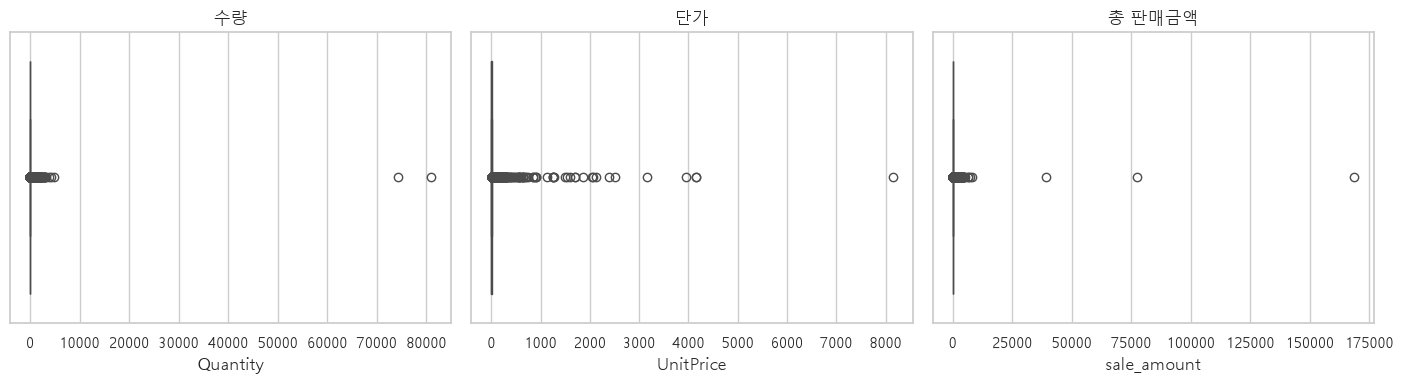

In [9]:
plt.figure(figsize = (14,4))

plt.subplot(1,3,1)
sns.boxplot(x = df_clean['Quantity'])
plt.title('수량')

plt.subplot(1,3,2)
sns.boxplot(x = df_clean['UnitPrice'])
plt.title('단가')

plt.subplot(1,3,3)
sns.boxplot(x = df_clean['sale_amount'])
plt.title('총 판매금액')

plt.tight_layout()
plt.show()

소수 고객의 구매 금액이 매우 큰 경우가 많다.                                             
실제 데이터이기 때문에 IQR 이상치 제거보다는 로그변환 정도 하면 분포를 눌러줄 수 있다.            

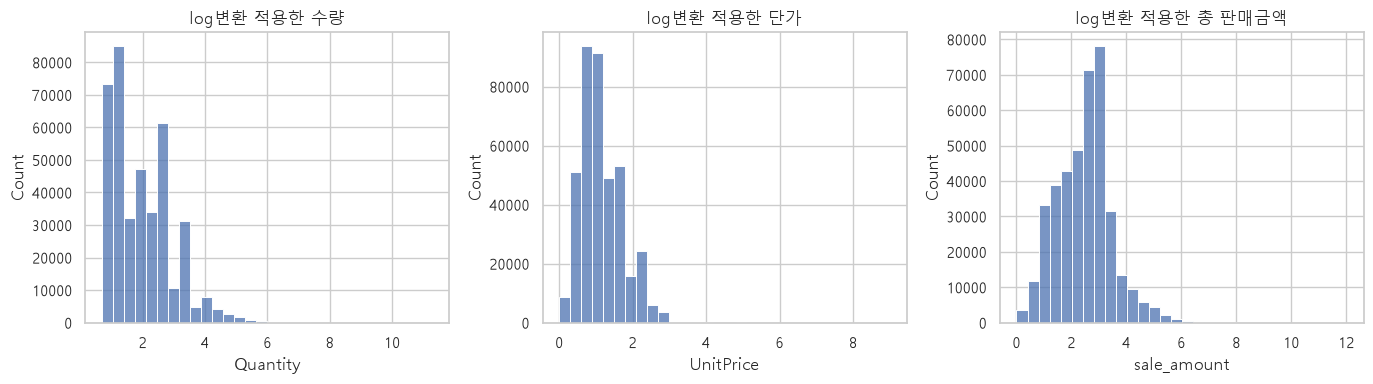

In [10]:
plt.figure(figsize = (14,4))

plt.subplot(1,3,1)
sns.histplot(np.log1p(df_clean['Quantity']), bins = 30)
plt.title('log변환 적용한 수량')

plt.subplot(1,3,2)
sns.histplot(np.log1p(df_clean['UnitPrice']), bins = 30)
plt.title('log변환 적용한 단가')

plt.subplot(1,3,3)
sns.histplot(np.log1p(df_clean['sale_amount']), bins = 30)
plt.title('log변환 적용한 총 판매금액')

plt.tight_layout()
plt.show()

6. 국가별 거래 현황 확인

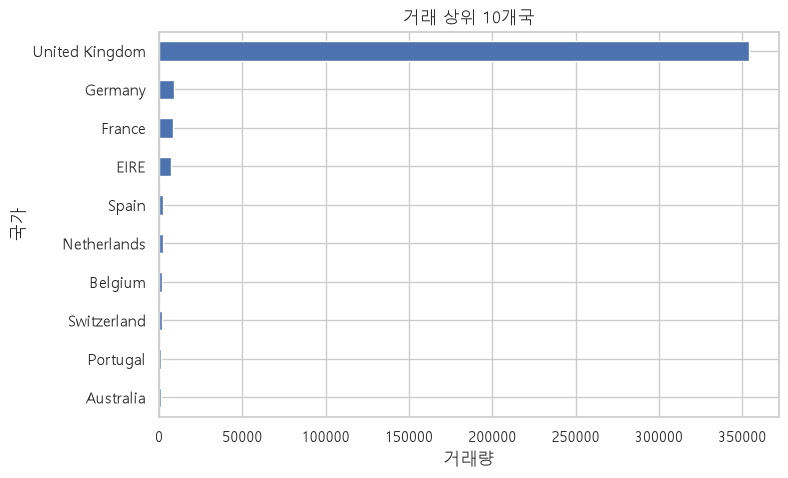

In [11]:
country_counts = df_clean['Country'].value_counts().head(10)

plt.figure(figsize = (8,5))
country_counts.sort_values().plot(kind='barh')
plt.title('거래 상위 10개국')
plt.xlabel('거래량')
plt.ylabel('국가')
plt.show()

In [12]:
customer_sales = df_clean.groupby('CustomerID')["sale_amount"].sum().sort_values(ascending = False)

customer_sales.head(10)


CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: sale_amount, dtype: float64

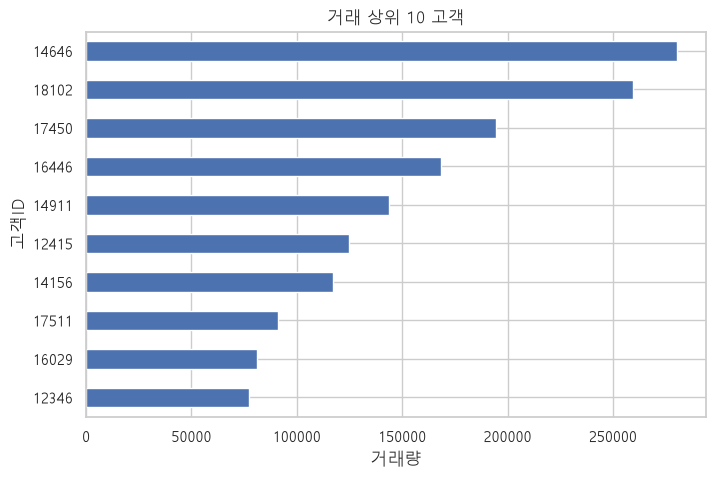

In [13]:
top10 = customer_sales.head(10).sort_values()

plt.figure(figsize = (8,5))
top10.plot(kind = 'barh')
plt.title('거래 상위 10 고객')
plt.xlabel('거래량')
plt.ylabel('고객ID')
plt.show()

In [14]:
# 상위 10%% 고객이 차지하는 매출 비중 계산

total_customers =  customer_sales.shape[0]               # 전체 고객수
top_10_percent_cnt = max(1, int(total_customers * 0.1))  # 상위 10% 고객 수

# customer_sales는 내림차순 되어있는 상태
top_10_sales = customer_sales.iloc[:top_10_percent_cnt].sum() # 상위 10% 고객의 매출 합
total_sales = customer_sales.sum()
top_10_ratio = top_10_sales / total_sales

print(f"전체 고객 수 : {total_customers}")
print(f"상위 10% 고객 수 : {top_10_percent_cnt}")
print(f"상위 10% 고객의 매출 비중 : {round(top_10_ratio, 4)}")

전체 고객 수 : 4338
상위 10% 고객 수 : 433
상위 10% 고객의 매출 비중 : 0.6133


고객 집단을 나눠 관리하는 것이 효율적으로 보인다.
고매출 집단 => 유지전략
저매출 집단 => 방문 유도 전략

8. RFM 데이터 만들기
    Recency 지표 (최근 구매일로부터 지난 일수): 작을수록 최근에 구매한 고객
    Frequency 지표 (구매횟수): 클수록 자주 구매한 고객
    Monetary 지표 (총 구매 금액): 클수록 매출 기여도가 큰 고객

In [15]:
# 기준날짜 : 데이터에서 가장 최근 구매일 + 1일

reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days = 1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [16]:
rfm_df = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency = ("InvoiceDate", lambda x:(reference_date - x.max()).days),
        Frequency = ("InvoiceNo", "nunique"),
        Monetary = ("sale_amount", "sum")
    )
    .reset_index()
)

rfm_df = rfm_df[rfm_df["Monetary"] > 0]

rfm_df

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4333,18280,278,1,180.60
4334,18281,181,1,80.82
4335,18282,8,2,178.05
4336,18283,4,16,2094.88


In [17]:
rfm_df[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


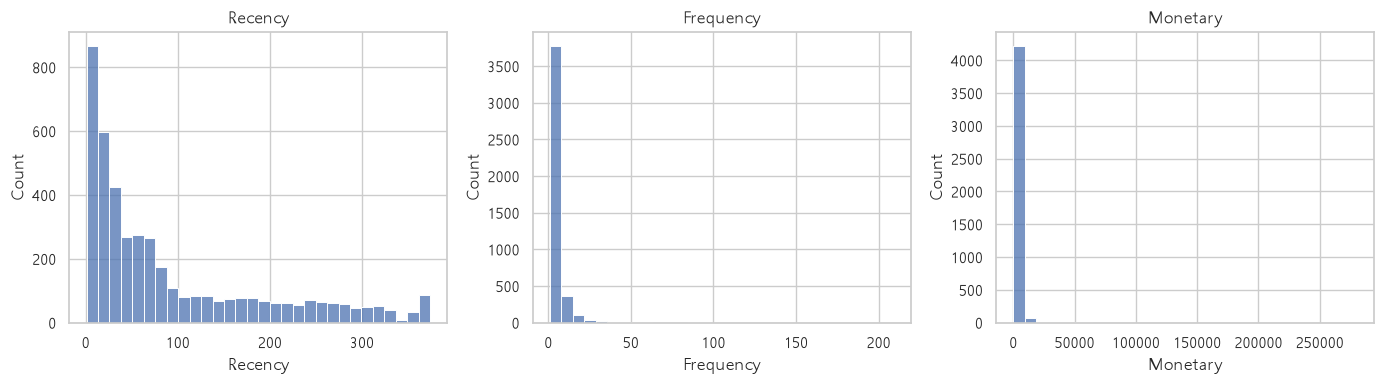

In [18]:
plt.figure(figsize = (14,4))

for idx, col in enumerate(['Recency','Frequency','Monetary'],start = 1):
    plt.subplot(1, 3, idx)
    sns.histplot(rfm_df[col], bins = 30)
    plt.title(col)

plt.tight_layout()
plt.show()    

Monetary는 일부 고객이 매우 큰 값을 가져 K-Means같은 거리기반 알고리즘에 적용하면 변수의 영향이 지나치게 커질 위험이 있다.      
그래서 log1p로 분포를 완화하고, StandatdScaler로 스케일링 작업을 진행해준다.

9. 로그 변환과 스케일링
    - log1p()로 치우친 분포 완화
    - StandardScaler로 평균 0, 표준편차 1 형태로 반환

In [19]:
rfm_features = ['Recency','Frequency','Monetary']

rfm_log = rfm_df[rfm_features].apply(np.log1p) # 로그로 변환

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


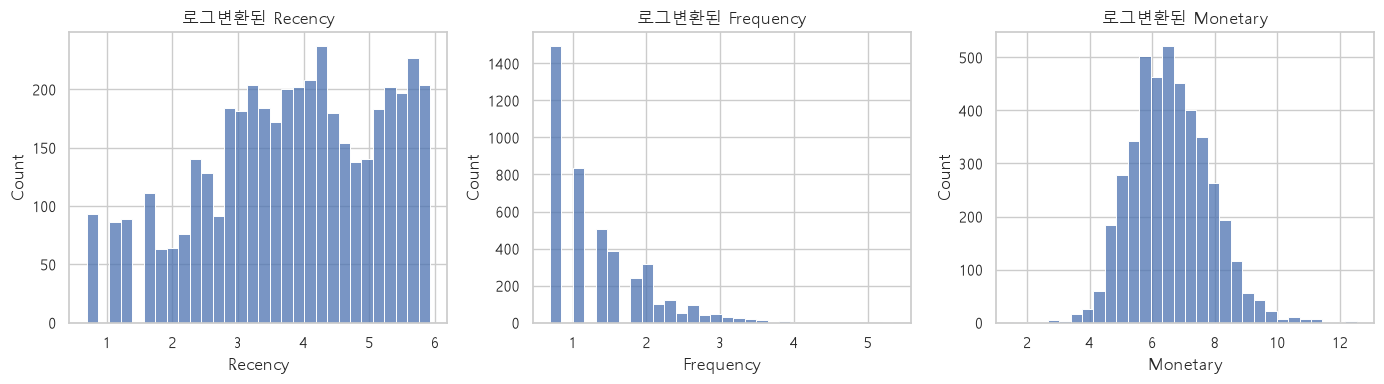

In [20]:
plt.figure(figsize=(14, 4))

for idx, col in enumerate(rfm_features, start=1):
    plt.subplot(1, 3, idx)
    sns.histplot(rfm_log[col], bins=30)
    plt.title(f"로그변환된 {col}")

plt.tight_layout()
plt.show()

In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(rfm_log)

scaled_data

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

10. 적절한 군집 수 K개 선택하기
- 두 개의 기준
    - Elbow Method : 군집 내 거리 합이 급격하게 줄어드는 지점을 확인
    - Shilhouette Score : 군집이 얼마나 잘 분리되었는지 확인

- 실제로는 실제 현실의 해석 가능성 + 비즈니스 활용 가능성

In [22]:
k_values = range(2,9)    # k값 테스트 2~8
 
inertia_list = []        # K-Means 군집 내 거리 합
silhoutte_list = []      # 실루엣 점수

for k in k_values:
    kmeans = KMeans(
        n_clusters = k,        # 군집 개수 2~8
        random_state = SEED,   
        n_init = 10            # 초기 중심점을 10번 바꿔서 가장 좋은 결과를 사용
        ) 

    # 학습 및 군집 라벨 예측
    labels = kmeans.fit_predict(scaled_data)

    inertia_list.append(kmeans.inertia_)         # 각 데이터가 본인의 군집 중심과 얼마나 가까운지 나타내는 값

    sample_size = min(1000, len(scaled_data))    # 최대 1000갸ㅐ의 샘플만 사용
    score = silhouette_score(
        scaled_data,                             # 스케일링 된 RFM 데이터
        labels,                                  # KMeans가 예측한 군집 라벨
        sample_size = sample_size, 
        random_state = SEED
    )
    silhoutte_list.append(score)

k_result = pd.DataFrame({
    "k" : list(k_values),
    "inertia" : inertia_list,
    "silhouette_score" : silhoutte_list
})    

k_result

,k,inertia,silhouette_score
0,2,6481.225323,0.429084
1,3,4867.846645,0.332634
2,4,3938.509954,0.334941
3,5,3295.976329,0.317371
4,6,2855.011247,0.317349
5,7,2548.914324,0.311720
6,8,2336.777508,0.298899


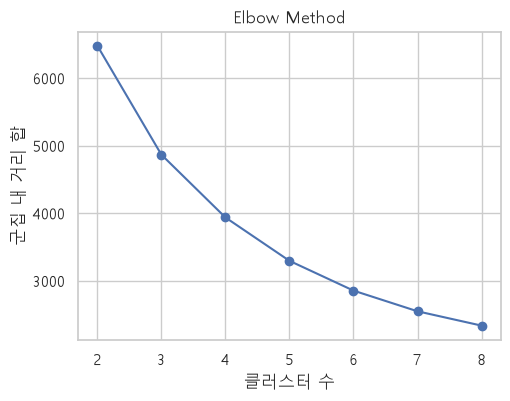

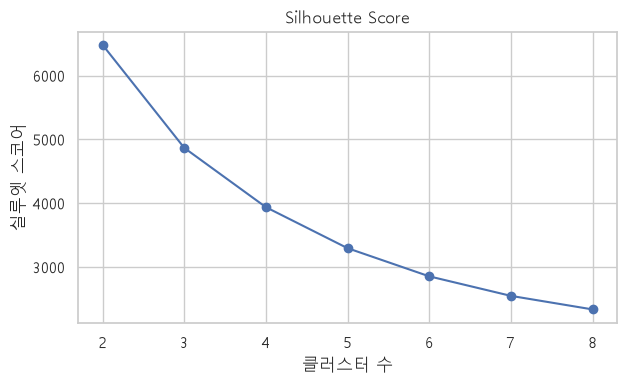

In [23]:
plt.figure(figsize = (12,4))

plt.subplot(1, 2, 1)
plt.plot(k_result["k"], k_result["inertia"], marker = 'o')
plt.title('Elbow Method')
plt.xlabel('클러스터 수')
plt.ylabel('군집 내 거리 합')

plt.figure(figsize = (12,4))

plt.subplot(1, 2, 2)
plt.plot(k_result["k"], k_result["inertia"], marker = 'o')
plt.title('Silhouette Score')
plt.xlabel('클러스터 수')
plt.ylabel('실루엣 스코어')

plt.tight_layout()
plt.show()


k = 4 지표상으로는 적절해 보입니다.
그렇지만 해석을 편하게 하기 위해 K = 3 으로 가도록 하겠습니다.        

11. K=Means 군집화

In [24]:
K = 3

Kmeans = KMeans(n_clusters = K, random_state = SEED, n_init = 10)
rfm_df["cluster"] = kmeans.fit_predict(scaled_data)

rfm_df.head

<bound method NDFrame.head of       CustomerID  Recency  Frequency  Monetary  cluster
0          12346      326          1  77183.60        4
1          12347        2          7   4310.00        5
2          12348       75          4   1797.24        2
3          12349       19          1   1757.55        2
4          12350      310          1    334.40        0
...          ...      ...        ...       ...      ...
4333       18280      278          1    180.60        0
4334       18281      181          1     80.82        0
4335       18282        8          2    178.05        7
4336       18283        4         16   2094.88        5
4337       18287       43          3   1837.28        2

[4338 rows x 5 columns]>

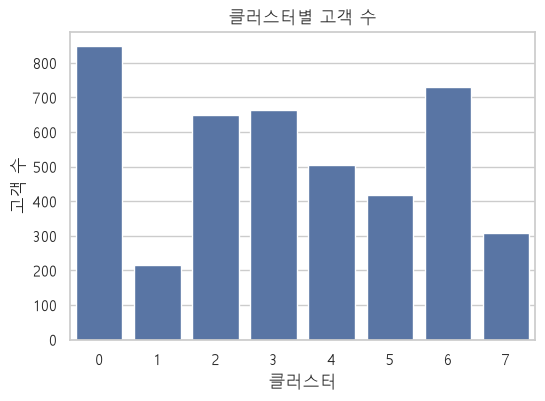

In [25]:
cluster_counts = rfm_df['cluster'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x = cluster_counts.index, y= cluster_counts.values)
plt.title('클러스터별 고객 수')
plt.xlabel('클러스터')
plt.ylabel('고객 수')
plt.show()

In [26]:
final_silhouette = silhouette_score(
    scaled_data, 
    rfm_df['cluster'], 
    sample_size = min(1000, len(scaled_data)),
    random_state = SEED
)

final_silhouette


0.29889853238136876

silhouette_score = -1 ~ 1
0에 가까울수록 군집 경계가 모호하다.
음수에 가까울수록 다른 군집과 더 가까운 데이터가 많다.

아주 낮지는 않지만 고객 데이터 특성상 패턴이 연속적인 면이 있어 실루엣 점수상 안 좋게 나올 수 있다.

12. PCA로 군집 결과 시각화

In [27]:
pca = PCA(n_components = 2, random_state = SEED)
pca_data = pca.fit_transform(scaled_data)

rfm_df['pca_x'] = pca_data[:,0]
rfm_df['pca_y'] = pca_data[:,1]

print(f"PCA 1, 2축 설명 분산 비율 : {pca.explained_variance_ratio_}")
print(f"PCA 누적 설명 분산 비율 : {pca.explained_variance_ratio_.sum()}")


PCA 1, 2축 설명 분산 비율 : [0.75102042 0.18759201]
PCA 누적 설명 분산 비율 : 0.9386124314129809


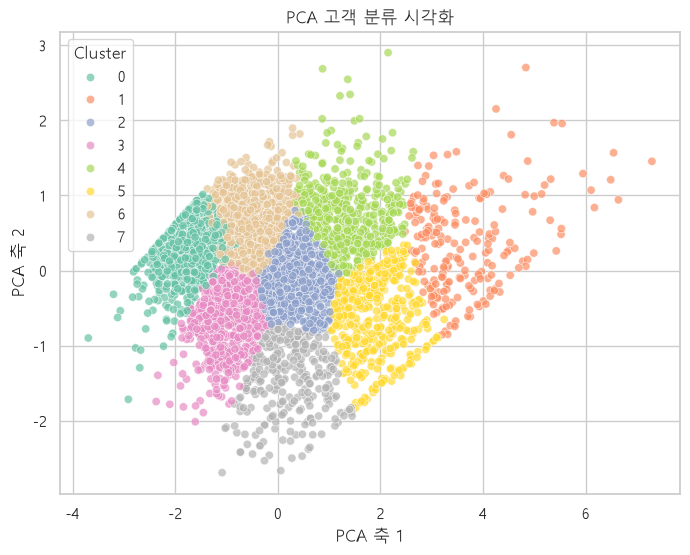

In [28]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data = rfm_df,
    x = "pca_x",
    y = "pca_y",
    hue= "cluster",
    palette = "Set2",
    alpha = 0.7
)

plt.title('PCA 고객 분류 시각화')
plt.xlabel('PCA 축 1')
plt.ylabel('PCA 축 2')
plt.legend(title="Cluster")
plt.show()

군집 간 차이가 비교적 명확하게 분리되어 있다.
겹치는 부분은 고객의 행동 양식이 연속적인 경우이다.

13. 군집별 RFM 특성 해석
- 각 군집이 어떤 고객군인지 해석해보기


In [29]:
cluster_summary = (
    rfm_df
    .groupby("cluster")
    .agg(
        customer_count = ("CustomerID","count"),
        recency_mean = ("Recency","median"),
        recency_median = ("Recency","median"),
        frequency_mean = ("Frequency","mean"),
        frequency_median = ("Frequency","median"),
        monetary_median = ("Monetary", "median"),
        monetary_sum = ("Monetary", "sum"),
    )
    .round(2)
)

cluster_summary

,customer_count,recency_mean,recency_median,frequency_mean,frequency_median,monetary_median,monetary_sum
cluster,,,,,,,
0,848,246.0,246.0,1.15,1.0,208.81,197080.42
1,216,4.0,4.0,25.84,19.0,8174.80,4085057.53
2,649,30.0,30.0,3.37,3.0,945.58,694734.60
3,665,46.0,46.0,1.25,1.0,272.22,190852.67
4,504,38.0,38.0,7.28,7.0,2725.79,1838751.59
5,418,6.0,6.0,7.05,7.0,2093.60,1039277.35
6,731,130.0,130.0,2.30,2.0,771.91,704482.66
7,307,8.0,8.0,2.14,2.0,452.24,161171.08


cluster 0이 VIP         
cluster 1이 휴면고객      
cluster 2이 일반고객         

recency가 낮다 -> 최근에 구매한 고객          
frequency가 높다 -> 자주 구매한 고객          
monetary 거 높다 -> 구매금액이 큰 고객          


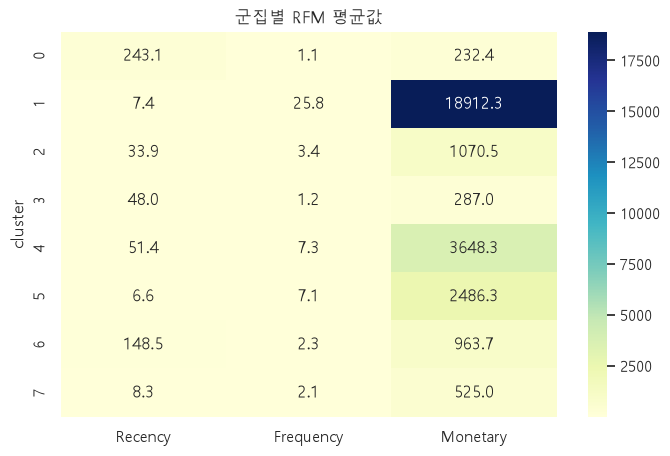

In [30]:
# 군집별 RFM 평균값 시각화
cluster_profile = rfm_df.groupby("cluster")[rfm_features].mean()

plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap='YlGnBu'    
)

plt.title('군집별 RFM 평균값')
plt.show()

14.군집 이름 붙이기

In [33]:
# RFM 지표를 이용해 고객 등급 분류
def assign_segment_name(row, summary):
    
    recency_rank = summary['recency_mean'].rank(ascending=True)       # 최근 방문일이 낮을수록 좋은 순위
    frequency_rank = summary['frequency_mean'].rank(ascending=False)  # 자주 방문할수록 좋은 순위
    monetary_rank = summary['monetary_mean'].rank(ascending=False)    # 구매금액이 클수록 좋은 순위

    cluster_id = row.name    # 인덱스를 뽑아 cluster_id로 사용

    if(
        recency_rank.loc[cluster_id] == 1
        and frequency_rank.loc[cluster_id] <= 2
        and monetary_rank.loc[cluster_id] <= 2
    ):
        return "VIP / 핵심 고객"

    if recency_rank.loc[cluster_id] == recency_rank.max():
        return "이탈 위험 고객"

    return "일반 / 성장 가능 고객"

    cluster_summary["segment_name"] = cluster_summary.apply(
        lambda row: assign_segment_name(row, cluster_summary),
        axis = 1
    )        
    cluster_summary

In [34]:
segment_map = cluster_summary["segment_name"].to_dict()
segment_map

KeyError: 'segment_name'

In [ ]:
rfm_df["segment_name"] = rfm_df["cluster"].map(segment_map)

rfm_df.head()

NameError: name 'segment_map' is not defined